# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

## The Dataset

TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace.

In [1]:
!pip install datasets

In [2]:
pip install -U datasets


Note: you may need to restart the kernel to use updated packages.


In [3]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

## Tokenize the Dataset

In [4]:

import os




if os.path.exists("train.bin"):
    os.remove("train.bin")
    print("Deleted old train.bin")
if os.path.exists("val.bin"):
    os.remove("val.bin")
    print("Deleted old val.bin")


    
import tiktoken
import numpy as np
from tqdm.auto import tqdm
from datasets import load_dataset


try:
    ds
except NameError:
    print("Loading dataset...")
    ds = load_dataset("roneneldan/TinyStories")


def process(example):
    
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")
    
    ids = enc.encode_ordinary(example['text'])
    ids.append(enc.eot_token)
    return {'ids': ids, 'len': len(ids)}


if not os.path.exists("train.bin"):
    print("Tokenizing dataset... (Using 8 cores)")
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8, 
    )
    
  
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 
        
       
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        
       
        total_batches = 1024
        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        
        arr.flush()
        print(f"Saved {filename}")

else:
    print("train.bin already exists! Skipping tokenization.")

Deleted old train.bin
Tokenizing dataset... (Using 8 cores)


writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

Saved train.bin


writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

Saved validation.bin


## Step 3: Create Input-Output batches for the dataset

In [5]:

def get_batch(split):
  
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
       
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [7]:
config = GPTConfig(
    vocab_size=50257,     
    block_size=128,       
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## the loss function

In [8]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [9]:

import torch
from contextlib import nullcontext

learning_rate = 1e-4 
max_iters = 20000 
warmup_steps = 1000 
min_lr = 5e-4 
eval_iters = 500
batch_size = 32 
block_size = 128 

gradient_accumulation_steps = 32 

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' 



dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' 
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

## Step 7: Define SLM Training Configuration Part 2

In [10]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR


optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay


scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

C:\Users\aniru\AppData\Local\Temp\ipykernel_17040\2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


## Step 8: Pre-train the SLM

In [11]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []


model = model.to(device)


for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

   
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

C:\Users\aniru\anaconda3\envs\slm-env\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 500: train loss 9.4729, val loss 9.4773
The current learning rate: 0.00007


C:\Users\aniru\anaconda3\envs\slm-env\lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 1000: train loss 8.4918, val loss 8.4959
The current learning rate: 0.00010
Epoch 1500: train loss 7.5348, val loss 7.5348
The current learning rate: 0.00010
Epoch 2000: train loss 6.6894, val loss 6.6858
The current learning rate: 0.00010
Epoch 2500: train loss 5.9896, val loss 5.9845
The current learning rate: 0.00011
Epoch 3000: train loss 5.4814, val loss 5.4818
The current learning rate: 0.00011
Epoch 3500: train loss 5.0563, val loss 5.0547
The current learning rate: 0.00012
Epoch 4000: train loss 4.7367, val loss 4.7288
The current learning rate: 0.00012
Epoch 4500: train loss 4.4832, val loss 4.4817
The current learning rate: 0.00013
Epoch 5000: train loss 4.2823, val loss 4.2851
The current learning rate: 0.00014
Epoch 5500: train loss 4.1078, val loss 4.1016
The current learning rate: 0.00015
Epoch 6000: train loss 3.9423, val loss 3.9462
The current learning rate: 0.00016
Epoch 6500: train loss 3.8165, val loss 3.8114
The current learning rate: 0.00018
Epoch 7000: trai

## Step 9: Plot the SLM Loss Function

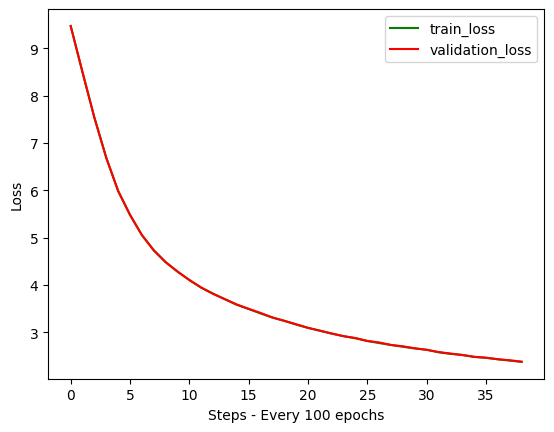

In [12]:
!pip install matplotlib

import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Step 10: Run SLM Inference on our trained model

In [13]:

model = GPT(config)  
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


C:\Users\aniru\AppData\Local\Temp\ipykernel_17040\1220266581.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_params_path, map

<All keys matched successfully>

In [23]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. He had never seen before so creamy. He had made a wonderful experience for the place. He was curious.

Next all of his friends would smell so Tim! He knew he needed more money so much most money not in the place. He bought money, meat and imagined so manylad!"

Sarah and his friends had fun! They talked all news and the fun and decided to find even more mouths to eat when it was safer.<|endoftext|>Once upon a time, there was a little boy who was very cold. He had ice-€™s eyes and wanted to eat it. So he went outside soon played with his friends.

One day, the sun was enormous and strangeella was too big! The boy was so happy that he began to laugh bigger than the special. Before he split his tree, the monkey was filled with joy.

Suddenly a huge bottle stopped sandwiches. The boy yawned and waved at a happy smile. He was so happy. 


In [24]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods. She peeked out a mysterious fox or shy some noise. Suddenly, the fox tufused and a giant fox were very quiet and what was happening. The gentle creature thanked the fox and asked some questions to the fox replied â€ and so alone. He went back in and chased the fox around in.

The young man was very happy to see lots of bugs and birds in a large house. The fox was so happy and then everyone was happy and happily ever!<|endoftext|>Inside the forest was an amazing jolly owl. After walking boxes of thick costumes looking for a new special decision. Toby jungle wanted to be the peace with most. So he marched up to the forest.

Suddenly, Maria saw a little eagle. He decided to scrubbed by lighter noises and felt beautiful outside. 

All the huge bull's eyes widened in trouble, but he never saw an forget. It was the palace ever," she said. Dave quarreled and it shone rainbow


In [28]:
import torch
import random

class StoryDirectorAgent:
    def __init__(self, model, enc, device):
        self.model = model
        self.enc = enc
        self.device = device

    def generate_directed_story(self, start_prompt, required_word, max_retries=4):
        print(f"\n[DIRECTOR AGENT] Starting process...")
        print(f"[GOAL] Write a story about '{start_prompt}' that must contain: '{required_word}'")

        current_prompt = start_prompt
        
        # A "Bag of Tricks" for the Agent to use if the model fails
        strategies = [
            f"{start_prompt} Suddenly, a huge {required_word} appeared right in front of them.",
            f"{start_prompt} They looked down and saw a {required_word} on the ground.",
            f"{start_prompt} 'Look! It is a {required_word}!' they shouted.",
            f"{start_prompt} The most important thing in the room was the {required_word}.",
            f"{start_prompt} Everyone was talking about the magical {required_word}."
        ]

        for attempt in range(1, max_retries + 1):
            print(f"\n--- Attempt {attempt} ---")

            # 1. GENERATE
            input_ids = self.enc.encode_ordinary(current_prompt)
            x = torch.tensor(input_ids, dtype=torch.long, device=self.device).unsqueeze(0)
            output_ids = self.model.generate(x, max_new_tokens=150, temperature=0.8)
            generated_text = self.enc.decode(output_ids[0].tolist())

            # Preview
            preview = generated_text.replace('\n', ' ')[:100]
            print(f"[Draft Story]: {preview}...")

            # 2. CHECK
            if required_word.lower() in generated_text.lower():
                print(f"[SUCCESS] The word '{required_word}' was found!")
                print("-" * 30)
                return generated_text
            
            else:
                print(f"[FAIL] The word '{required_word}' is missing.")
                
                # 3. DYNAMIC CORRECTION (The new logic)
                # Instead of always doing the same thing, pick a new strategy
                if attempt < max_retries:
                    new_strategy = strategies[attempt % len(strategies)]
                    print(f"[REFLECTION] Strategy A failed. Switching tactics...")
                    print(f"[ACTION] Trying new prompt context: '...{new_strategy[-20:]}'")
                    current_prompt = new_strategy

        return "Agent gave up. The model is too stubborn."

# --- RUN THE AGENT (INTERACTIVE) ---
agent = StoryDirectorAgent(model, enc, device)

print("="*50)
print("  ADVANCED STORY DIRECTOR  ")
print("="*50)

user_topic = input("\nENTER STORY START (e.g., 'Once upon a time'): ") or "Once upon a time"
user_word = input("TARGET WORD: ") or "balloon"

final_story = agent.generate_directed_story(user_topic, user_word)

print("\n" + "="*40)
print("FINAL APPROVED STORY:")
print(final_story)
print("="*40)

  ADVANCED STORY DIRECTOR  



ENTER STORY START (e.g., 'Once upon a time'):  jojo was a mad man
TARGET WORD:  fun



[DIRECTOR AGENT] Starting process...
[GOAL] Write a story about 'jojo was a mad man' that must contain: 'fun'

--- Attempt 1 ---
[Draft Story]: jojo was a mad man who was always carrying him.  The wizard said, "You did not have to stop getting ...
[FAIL] The word 'fun' is missing.
[REFLECTION] Strategy A failed. Switching tactics...
[ACTION] Trying new prompt context: '...a fun on the ground.'

--- Attempt 2 ---
[Draft Story]: jojo was a mad man They looked down and saw a fun on the ground. He wanted to see the fake man, but ...
[SUCCESS] The word 'fun' was found!
------------------------------

FINAL APPROVED STORY:
jojo was a mad man They looked down and saw a fun on the ground. He wanted to see the fake man, but it was too heavy for him. He said to the man, "Don't worry, sir. Come away." The man said, "Sure, but you have to go. The old man is not hurt. He makes a mess. He can hurt him and he can take care of you. He you have to be careful and to respect what people don't do if you 